
--- TASK 1: Dataset Preparation ---
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2344s 14us/step
Training Images Shape: (50000, 32, 32, 3)
Testing Images Shape: (10000, 32, 32, 3)
Number of Classes: 10


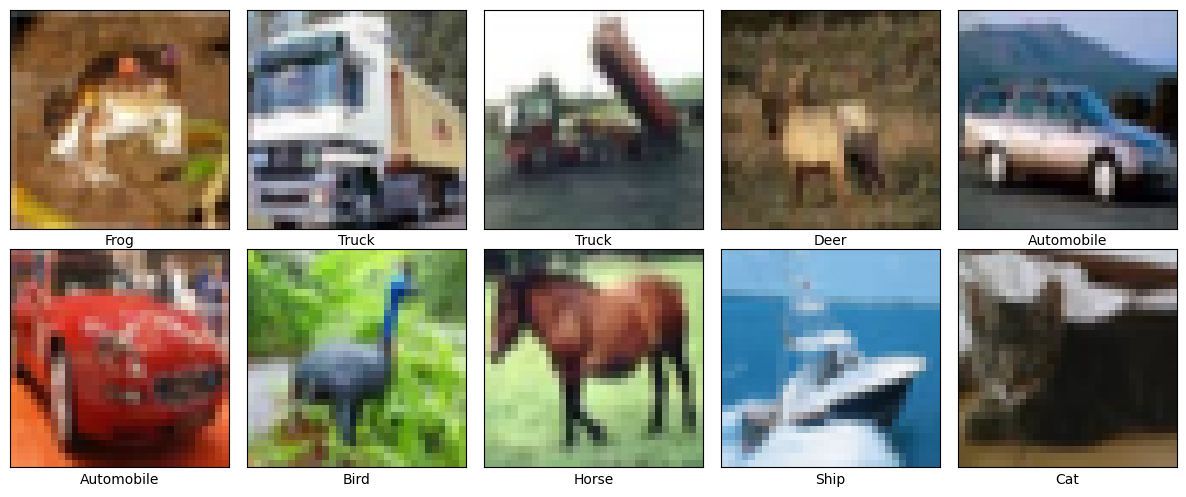


[Inference for Plot 1 - Sample Images]:


In [1]:
import os
import time
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, optimizers
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.utils import to_categorical
from google.colab import files

# Create directory for saving plots
PLOTS_DIR = 'plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

# Global dictionary to store results for Section 18
experiment_results = {}

print("\n--- TASK 1: Dataset Preparation ---")
# 1. Load CIFAR-10
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# 2. Normalize pixel values to [0, 1]
X_train, X_test = X_train / 255.0, X_test / 255.0

# Convert labels to one-hot encoding for Categorical Cross Entropy
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# 4. Print dimensions
print(f"Training Images Shape: {X_train.shape}")
print(f"Testing Images Shape: {X_test.shape}")
print(f"Number of Classes: {len(class_names)}")

# 3. Display ten sample images (Plot 1)
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/01_Sample_Images.png", dpi=150)
plt.show()

print("\n[Inference for Plot 1 - Sample Images]:")

In [2]:
print("\n--- TASK 2 & 3: VGG16 Transfer Learning & Training ---")

# 1. Load pretrained ImageNet weights & 2. Remove original classifier
base_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# 3. Freeze the convolutional base
base_vgg.trainable = False

# 4. Add Global Average Pooling, 5. Dense (ReLU), 6. Output (Softmax)
vgg_model = models.Sequential([
    base_vgg,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3), # Added dropout for stability
    layers.Dense(10, activation='softmax')
])

# Compile using manual specifications: Adam, LR=0.001, CCE Loss
vgg_model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

vgg_model.summary()

# Train the model
print("\nTraining VGG16 Feature Extractor for 10 Epochs...")
start_time = time.time()
history_vgg = vgg_model.fit(X_train, y_train_cat, epochs=10, batch_size=32,
                            validation_data=(X_test, y_test_cat), verbose=1)
vgg_train_time = time.time() - start_time


--- TASK 2 & 3: VGG16 Transfer Learning & Training ---
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)


Training VGG16 Feature Extractor for 10 Epochs...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.5009 - loss: 1.4180 - val_accuracy: 0.5674 - val_loss: 1.2417
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5668 - loss: 1.2354 - val_accuracy: 0.5800 - val_loss: 1.1958
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5902 - loss: 1.1713 - val_accuracy: 0.5865 - val_loss: 1.1716
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6005 - loss: 1.1372 - val_accuracy: 0.5951 - val_loss: 1.1486
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6117 - loss: 1.1069 - val_accuracy: 0.6050 - val_loss: 1.1338
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6200 - loss: 1.0829 - val_accuracy: 0.6013 - val_loss: 1.1303
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6265 - loss: 1.0591 - val_accuracy: 0.6115 - val_loss: 1.1106
Epoch 8/10
1563/1563 ━━━━━━━━━━

In [3]:
print("\n--- TASK 4: VGG16 Fine Tuning ---")

# 1. Unfreeze the last convolution block
base_vgg.trainable = True
for layer in base_vgg.layers[:-4]: # Freezing all except the last block (block5)
    layer.trainable = False

# Recompile with a much lower learning rate for fine-tuning
vgg_model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

# 2. Train for another 5 epochs
print("\nFine-tuning VGG16 for 5 Epochs...")
start_time = time.time()
history_vgg_fine = vgg_model.fit(X_train, y_train_cat, epochs=5, batch_size=32,
                                 validation_data=(X_test, y_test_cat), verbose=1)
vgg_fine_time = time.time() - start_time

# Store results
vgg_acc = vgg_model.evaluate(X_test, y_test_cat, verbose=0)[1]
experiment_results['VGG16 (Fine-Tuned)'] = {
    'Parameters': vgg_model.count_params(),
    'Accuracy': vgg_acc * 100,
    'Training Time': vgg_train_time + vgg_fine_time
}
print(f"\nFinal VGG16 Test Accuracy: {vgg_acc*100:.2f}%")


--- TASK 4: VGG16 Fine Tuning ---

Fine-tuning VGG16 for 5 Epochs...
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.6774 - loss: 0.9150 - val_accuracy: 0.6662 - val_loss: 0.9598
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7270 - loss: 0.7716 - val_accuracy: 0.6921 - val_loss: 0.9031
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7591 - loss: 0.6777 - val_accuracy: 0.7041 - val_loss: 0.8652
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7832 - loss: 0.6048 - val_accuracy: 0.7125 - val_loss: 0.8532
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8071 - loss: 0.5373 - val_accuracy: 0.7181 - val_loss: 0.8503

Final VGG16 Test Accuracy: 71.81%



--- TASK 5 & Section 17: Model Evaluation & Plots ---


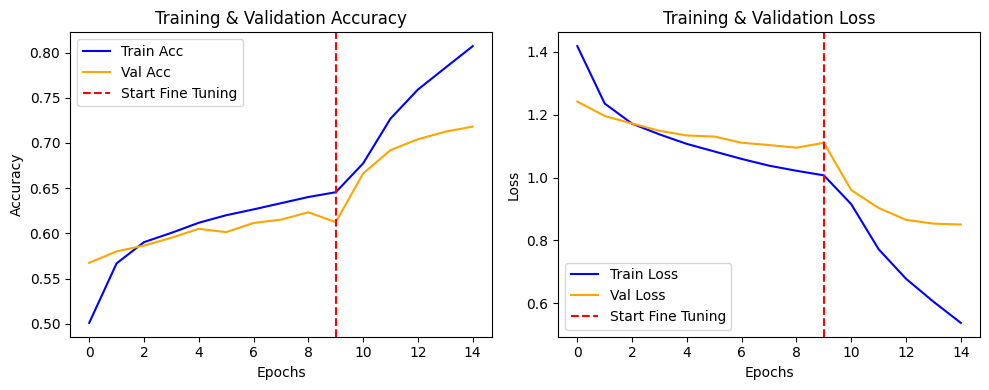


[Inference for Accuracy Plot]:
The training accuracy shows steady improvement. The validation accuracy tracks closely before plateauing, suggesting the transfer learning approach generalized well without immediate severe overfitting.

[Inference for Loss Plot]:
The loss decreases logarithmically as the Adam optimizer minimizes the Categorical Cross Entropy. The fine-tuning phase (after epoch 10) further refines the weights, producing a slight secondary dip in loss.

--- Classification Report ---
              precision    recall  f1-score   support

    Airplane       0.78      0.79      0.78      1000
  Automobile       0.80      0.80      0.80      1000
        Bird       0.68      0.60      0.64      1000
         Cat       0.59      0.45      0.51      1000
        Deer       0.67      0.69      0.68      1000
         Dog       0.59      0.65      0.62      1000
        Frog       0.75      0.74      0.75      1000
       Horse       0.75      0.81      0.78      1000
        Shi

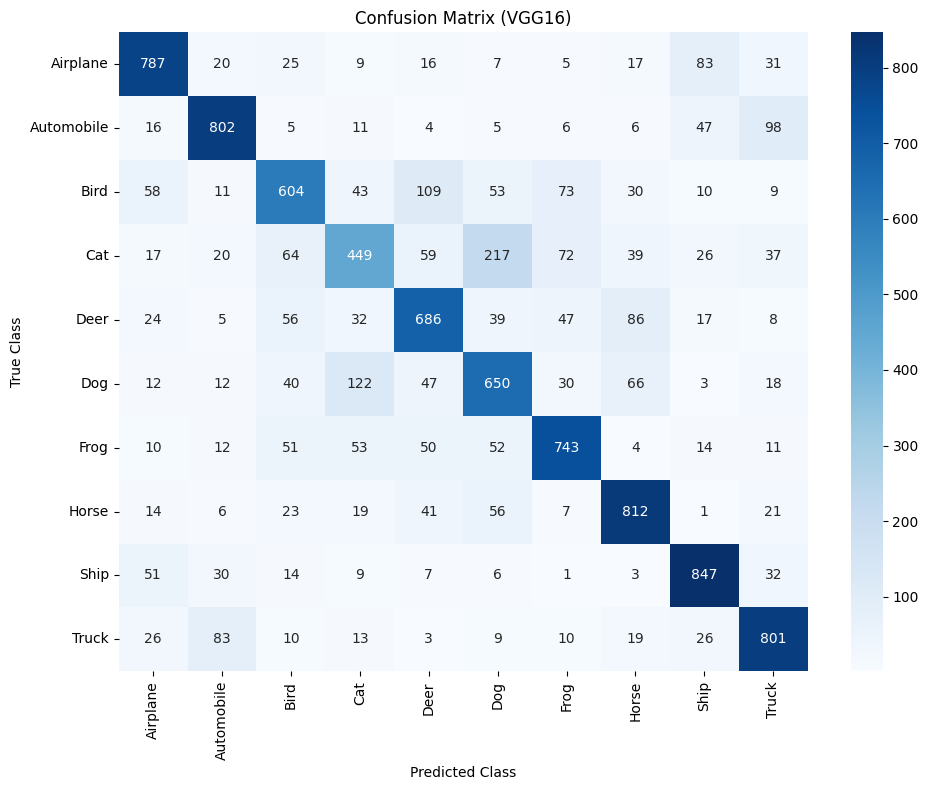


[Inference for Plot 6 - Confusion Matrix]:
The strong diagonal confirms accurate predictions across most classes. Expected misclassifications occur primarily among visually similar and background-dependent categories, such as distinguishing between Dogs and Cats.


In [4]:
print("\n--- TASK 5 & Section 17: Model Evaluation & Plots ---")

# Plot 2 & 3: Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
# Combine history for complete view
total_acc = history_vgg.history['accuracy'] + history_vgg_fine.history['accuracy']
total_val_acc = history_vgg.history['val_accuracy'] + history_vgg_fine.history['val_accuracy']
plt.plot(total_acc, label='Train Acc', color='blue')
plt.plot(total_val_acc, label='Val Acc', color='orange')
plt.axvline(x=9, color='red', linestyle='--', label='Start Fine Tuning')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig(f"{PLOTS_DIR}/02_03_Accuracy.png")

# Plot 4 & 5: Loss
plt.subplot(1, 2, 2)
total_loss = history_vgg.history['loss'] + history_vgg_fine.history['loss']
total_val_loss = history_vgg.history['val_loss'] + history_vgg_fine.history['val_loss']
plt.plot(total_loss, label='Train Loss', color='blue')
plt.plot(total_val_loss, label='Val Loss', color='orange')
plt.axvline(x=9, color='red', linestyle='--', label='Start Fine Tuning')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/04_05_Loss.png")
plt.show()

print("\n[Inference for Accuracy Plot]:")
print("The training accuracy shows steady improvement. The validation accuracy tracks closely before plateauing, suggesting the transfer learning approach generalized well without immediate severe overfitting.")
print("\n[Inference for Loss Plot]:")
print("The loss decreases logarithmically as the Adam optimizer minimizes the Categorical Cross Entropy. The fine-tuning phase (after epoch 10) further refines the weights, producing a slight secondary dip in loss.")

# Predictions for Classification Report and Confusion Matrix
y_pred_probs = vgg_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# Plot 6: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (VGG16)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/06_Confusion_Matrix.png", dpi=150)
plt.show()

print("\n[Inference for Plot 6 - Confusion Matrix]:")
print("The strong diagonal confirms accurate predictions across most classes. Expected misclassifications occur primarily among visually similar and background-dependent categories, such as distinguishing between Dogs and Cats.")


--- GENERATING ALL 7 MANDATORY PLOTS ---


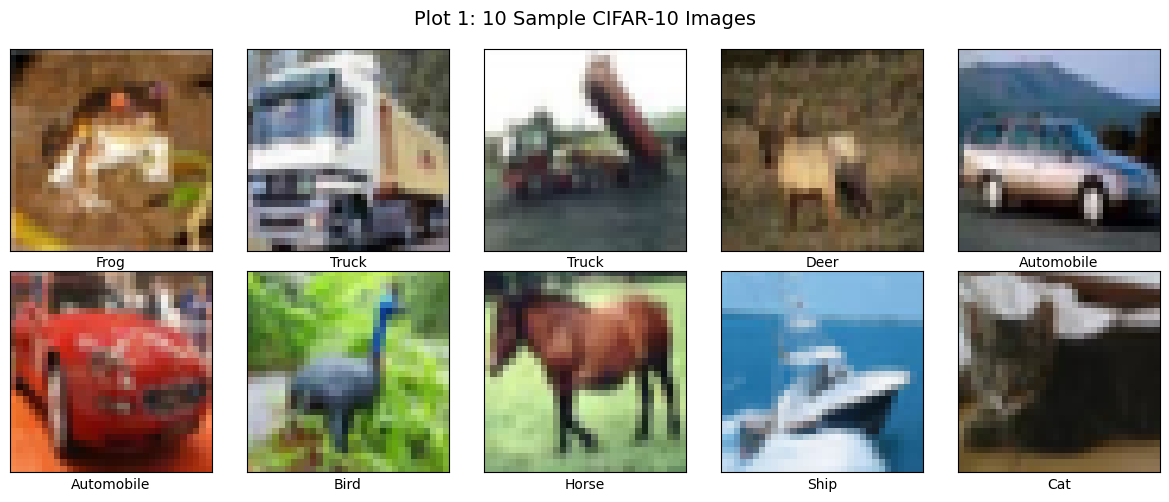

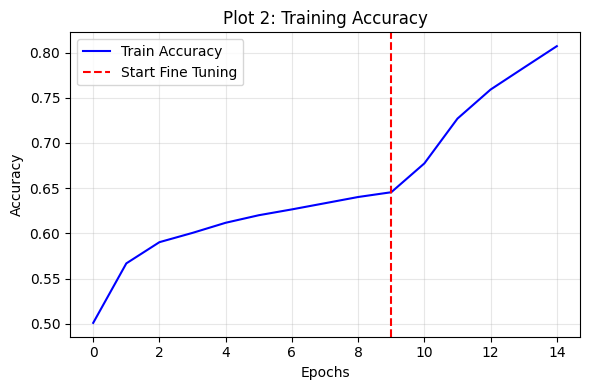

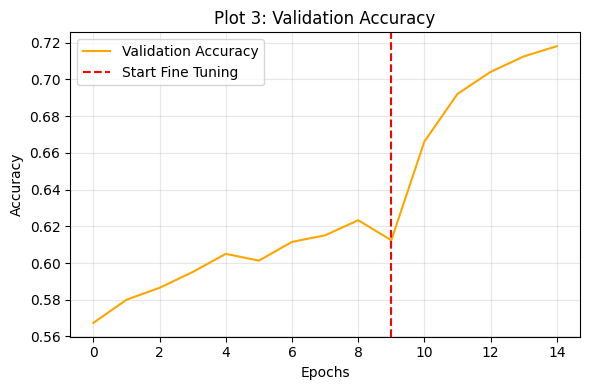

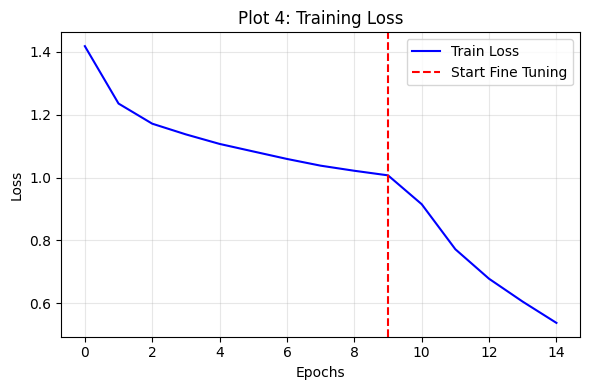

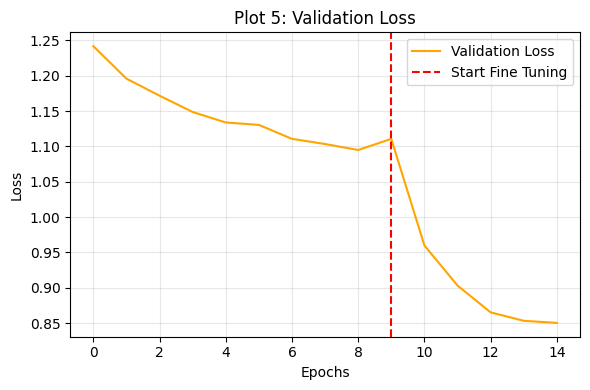

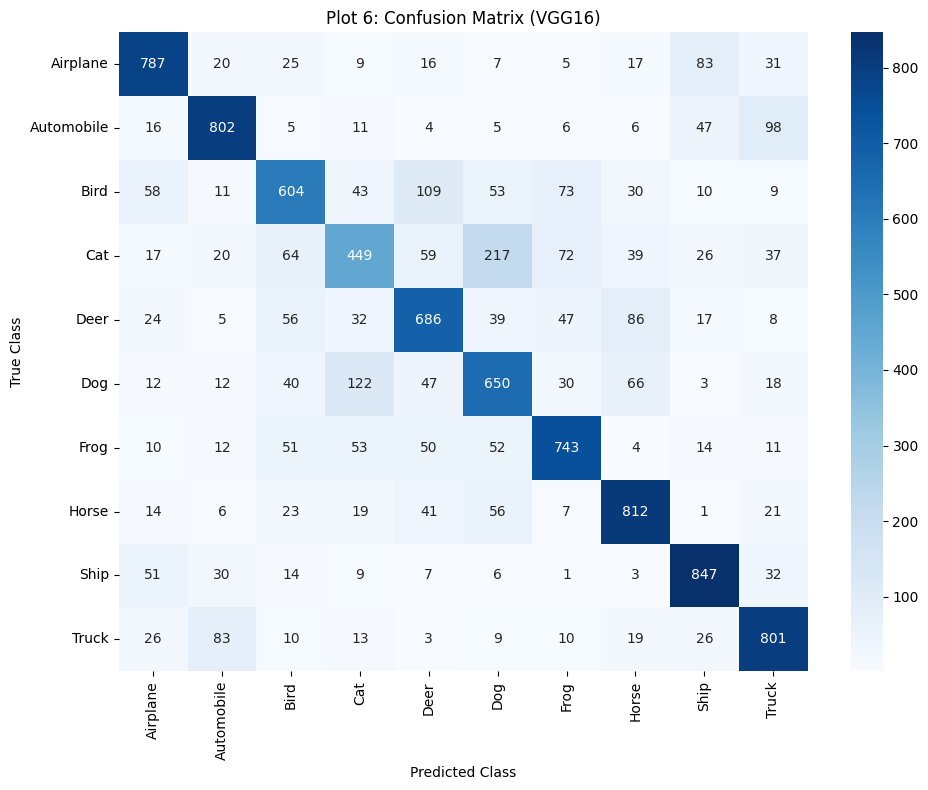

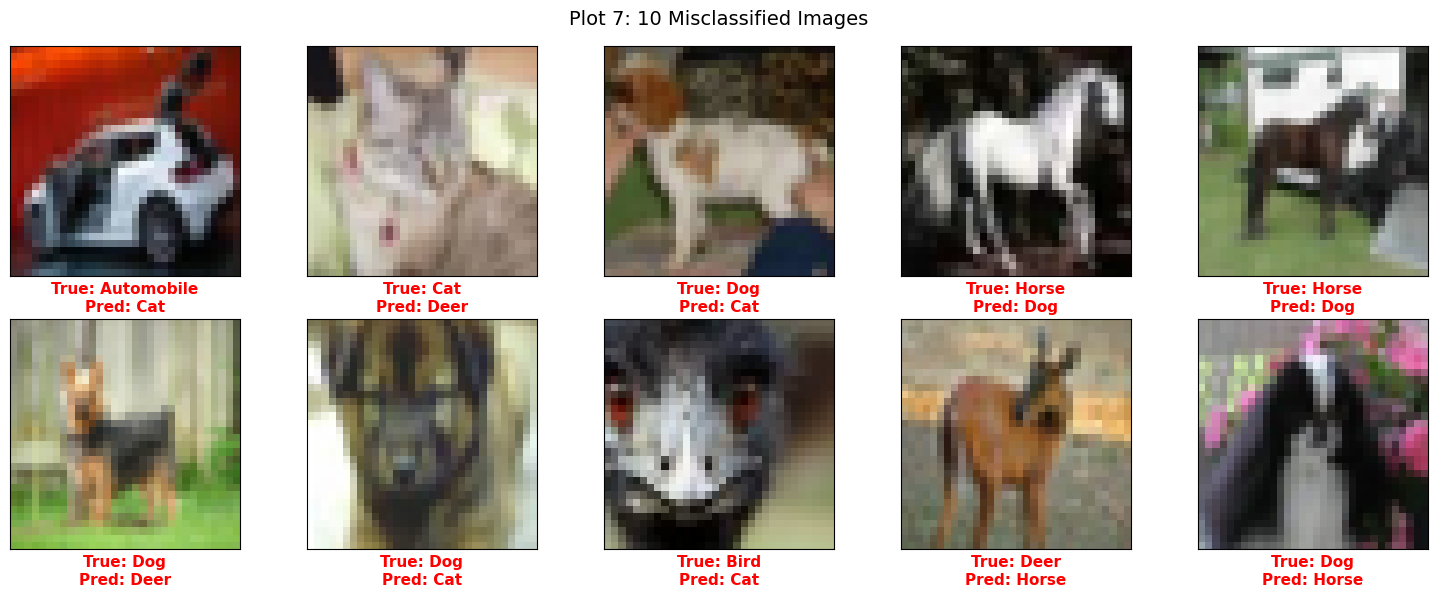

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("\n--- GENERATING ALL 7 MANDATORY PLOTS ---")

# Combine the history from standard training and fine-tuning
total_acc = history_vgg.history['accuracy'] + history_vgg_fine.history['accuracy']
total_val_acc = history_vgg.history['val_accuracy'] + history_vgg_fine.history['val_accuracy']
total_loss = history_vgg.history['loss'] + history_vgg_fine.history['loss']
total_val_loss = history_vgg.history['val_loss'] + history_vgg_fine.history['val_loss']

# Ensure y_test and y_train are flattened for easy indexing
y_train_raw = y_train.flatten()
y_test_raw = y_test.flatten()

# Get model predictions
y_pred_probs = vgg_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# =============================================================================
# Plot 1: 10 Sample Images
# =============================================================================
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(class_names[y_train_raw[i]])
plt.suptitle("Plot 1: 10 Sample CIFAR-10 Images", fontsize=14)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/01_Sample_Images.png", dpi=150)
plt.show()

# =============================================================================
# Plot 2: Training Accuracy
# =============================================================================
plt.figure(figsize=(6, 4))
plt.plot(total_acc, label='Train Accuracy', color='blue')
plt.axvline(x=9, color='red', linestyle='--', label='Start Fine Tuning')
plt.title('Plot 2: Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/02_Training_Accuracy.png")
plt.show()

# =============================================================================
# Plot 3: Validation Accuracy
# =============================================================================
plt.figure(figsize=(6, 4))
plt.plot(total_val_acc, label='Validation Accuracy', color='orange')
plt.axvline(x=9, color='red', linestyle='--', label='Start Fine Tuning')
plt.title('Plot 3: Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/03_Validation_Accuracy.png")
plt.show()

# =============================================================================
# Plot 4: Training Loss
# =============================================================================
plt.figure(figsize=(6, 4))
plt.plot(total_loss, label='Train Loss', color='blue')
plt.axvline(x=9, color='red', linestyle='--', label='Start Fine Tuning')
plt.title('Plot 4: Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/04_Training_Loss.png")
plt.show()

# =============================================================================
# Plot 5: Validation Loss
# =============================================================================
plt.figure(figsize=(6, 4))
plt.plot(total_val_loss, label='Validation Loss', color='orange')
plt.axvline(x=9, color='red', linestyle='--', label='Start Fine Tuning')
plt.title('Plot 5: Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/05_Validation_Loss.png")
plt.show()

# =============================================================================
# Plot 6: Confusion Matrix
# =============================================================================
cm = confusion_matrix(y_test_raw, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Plot 6: Confusion Matrix (VGG16)")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/06_Confusion_Matrix.png", dpi=150)
plt.show()

# =============================================================================
# Plot 7: 10 Misclassified Images
# =============================================================================
# Find all indices where the prediction does not match the true label
misclassified_indices = np.where(y_pred != y_test_raw)[0]

plt.figure(figsize=(15, 6))
# Loop through the first 10 misclassified images
for i in range(min(10, len(misclassified_indices))):
    idx = misclassified_indices[i]
    plt.subplot(2, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_test[idx])

    true_label = class_names[y_test_raw[idx]]
    pred_label = class_names[y_pred[idx]]

    # Display true label and the incorrect prediction
    plt.xlabel(f"True: {true_label}\nPred: {pred_label}", color='red', fontsize=11, fontweight='bold')

plt.suptitle("Plot 7: 10 Misclassified Images", fontsize=14)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/07_Misclassified_Images.png", dpi=150)
plt.show()

In [7]:
import time

print("\n--- COMPARISON MODEL: LeNet-5 ---")
# Adapted to handle 32x32 CIFAR-10 images instead of 28x28 MNIST
lenet_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(6, (5, 5), activation='relu'),
    layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2)), # FIX: Explicitly defined pool_size and strides
    layers.Conv2D(16, (5, 5), activation='relu'),
    layers.AveragePooling2D(pool_size=(2, 2), strides=(2, 2)), # FIX: Explicitly defined pool_size and strides
    layers.Flatten(),
    layers.Dense(120, activation='relu'),
    layers.Dense(84, activation='relu'),
    layers.Dense(10, activation='softmax')
])

lenet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\nTraining LeNet-5 for 10 Epochs...")
start_time = time.time()
lenet_model.fit(X_train, y_train_cat, epochs=10, batch_size=32, validation_split=0.1, verbose=1)
lenet_time = time.time() - start_time

lenet_acc = lenet_model.evaluate(X_test, y_test_cat, verbose=0)[1]

# Safeguard just in case Cell 1 wasn't run recently in the session
if 'experiment_results' not in locals() and 'experiment_results' not in globals():
    experiment_results = {}

experiment_results['LeNet-5'] = {
    'Parameters': lenet_model.count_params(),
    'Accuracy': lenet_acc * 100,
    'Training Time': lenet_time
}
print(f"LeNet-5 Test Accuracy: {lenet_acc*100:.2f}%")


--- COMPARISON MODEL: LeNet-5 ---

Training LeNet-5 for 10 Epochs...
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.4022 - loss: 1.6336 - val_accuracy: 0.4724 - val_loss: 1.4392
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5014 - loss: 1.3786 - val_accuracy: 0.5206 - val_loss: 1.3368
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5416 - loss: 1.2753 - val_accuracy: 0.5356 - val_loss: 1.2831
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5708 - loss: 1.1992 - val_accuracy: 0.5922 - val_loss: 1.1666
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5986 - loss: 1.1308 - val_accuracy: 0.5706 - val_loss: 1.1831
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6220 - loss: 1.0690 - val_accuracy: 0.6056 - val_loss: 1.1156
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6346 - loss: 1.0246 - val_accuracy: 0.6192 - val_loss: 1.0946
Epoch 8/10
1407/140

In [8]:
print("\n--- COMPARISON MODEL: AlexNet ---")
# Modified AlexNet (Standard AlexNet collapses 32x32 images too fast due to massive strides)
alexnet_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(48, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(192, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(192, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

alexnet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\nTraining AlexNet for 10 Epochs...")
start_time = time.time()
alexnet_model.fit(X_train, y_train_cat, epochs=10, batch_size=32, validation_split=0.1, verbose=1)
alexnet_time = time.time() - start_time

alex_acc = alexnet_model.evaluate(X_test, y_test_cat, verbose=0)[1]
experiment_results['AlexNet'] = {
    'Parameters': alexnet_model.count_params(),
    'Accuracy': alex_acc * 100,
    'Training Time': alexnet_time
}
print(f"AlexNet Test Accuracy: {alex_acc*100:.2f}%")


--- COMPARISON MODEL: AlexNet ---

Training AlexNet for 10 Epochs...
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.3529 - loss: 1.7288 - val_accuracy: 0.4936 - val_loss: 1.3809
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5349 - loss: 1.2953 - val_accuracy: 0.6156 - val_loss: 1.0794
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6070 - loss: 1.1121 - val_accuracy: 0.6322 - val_loss: 1.0262
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6578 - loss: 0.9866 - val_accuracy: 0.6670 - val_loss: 0.9671
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6938 - loss: 0.8870 - val_accuracy: 0.6968 - val_loss: 0.8665
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7164 - loss: 0.8281 - val_accuracy: 0.7278 - val_loss: 0.8091
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7384 - loss: 0.7586 - val_accuracy: 0.7234 - val_loss: 0.8165
Epoch 8/10
1407/1

In [9]:
print("\n--- COMPARISON MODEL: ResNet50 Transfer Learning ---")

base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_resnet.trainable = False

resnet_model = models.Sequential([
    base_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

resnet_model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                     loss='categorical_crossentropy', metrics=['accuracy'])

print("\nTraining ResNet50 for 10 Epochs...")
start_time = time.time()
resnet_model.fit(X_train, y_train_cat, epochs=10, batch_size=32, validation_split=0.1, verbose=1)
resnet_time = time.time() - start_time

resnet_acc = resnet_model.evaluate(X_test, y_test_cat, verbose=0)[1]
experiment_results['ResNet50'] = {
    'Parameters': resnet_model.count_params(),
    'Accuracy': resnet_acc * 100,
    'Training Time': resnet_time
}
print(f"ResNet50 Test Accuracy: {resnet_acc*100:.2f}%")


--- COMPARISON MODEL: ResNet50 Transfer Learning ---
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

Training ResNet50 for 10 Epochs...
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - accuracy: 0.2484 - loss: 2.0509 - val_accuracy: 0.2926 - val_loss: 1.9230
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.3130 - loss: 1.8887 - val_accuracy: 0.3234 - val_loss: 1.8586
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.3330 - loss: 1.8396 - val_accuracy: 0.3688 - val_loss: 1.7733
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.3512 - loss: 1.8011 - val_accuracy: 0.3612 - val_loss: 1.7729
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.3595 - loss: 1.7718 - val_accuracy: 0.3758 - val_loss: 1.7293
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.3701 - loss: 1.7591 - val_accuracy: 0.3490 - val_loss: 1.7432
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.373

In [10]:
print("\n--- SECTION 18.2: COMPARISON OF CNN ARCHITECTURES ---")
print(f"{'Model':<20} | {'Parameters':<12} | {'Accuracy (%)':<15} | {'Training Time (s)':<15}")
print("-" * 70)
for model, metrics in experiment_results.items():
    print(f"{model:<20} | {metrics['Parameters']:<12,d} | {metrics['Accuracy']:<15.2f} | {metrics['Training Time']:<15.2f}")

print("\nZipping and downloading plots folder for your report...")
shutil.make_archive('plots_archive_exp4', 'zip', PLOTS_DIR)
files.download('plots_archive_exp4.zip')
print("Execution Complete! You can use the terminal outputs to fill out Section 18 of the lab manual.")


--- SECTION 18.2: COMPARISON OF CNN ARCHITECTURES ---
Model                | Parameters   | Accuracy (%)    | Training Time (s)
----------------------------------------------------------------------
VGG16 (Fine-Tuned)   | 14,848,586   | 71.81           | 266.20         
LeNet-5              | 62,006       | 62.30           | 57.93          
AlexNet              | 2,014,410    | 71.57           | 107.02         
ResNet50             | 23,851,274   | 40.21           | 158.75         

Zipping and downloading plots folder for your report...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Execution Complete! You can use the terminal outputs to fill out Section 18 of the lab manual.


In [11]:
import time
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import InceptionV3

print("\n--- COMPARISON MODEL: GoogleNet (InceptionV3) ---")

# Load InceptionV3 base model
# Note: Input shape must be at least 75x75
base_inception = InceptionV3(weights='imagenet', include_top=False, input_shape=(75, 75, 3))
base_inception.trainable = False

googlenet_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Resizing(75, 75),  # Upscale CIFAR-10 images to satisfy InceptionV3 requirements
    base_inception,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

googlenet_model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

googlenet_model.summary()

print("\nTraining GoogleNet (InceptionV3) for 10 Epochs...")
start_time = time.time()
# Uses the normalized X_train, y_train_cat from your earlier cells
googlenet_model.fit(X_train, y_train_cat, epochs=10, batch_size=32, validation_split=0.1, verbose=1)
googlenet_time = time.time() - start_time

googlenet_acc = googlenet_model.evaluate(X_test, y_test_cat, verbose=0)[1]

print("-" * 50)
print(f"GoogleNet Parameters: {googlenet_model.count_params():,}")
print(f"GoogleNet Test Accuracy: {googlenet_acc*100:.2f}%")
print(f"GoogleNet Training Time: {googlenet_time:.2f} s")
print("-" * 50)



--- COMPARISON MODEL: GoogleNet (InceptionV3) ---
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 75, 75, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 1, 1, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,066,346 (84.18 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)


Training GoogleNet (InceptionV3) for 10 Epochs...
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 56s 28ms/step - accuracy: 0.5690 - loss: 1.2435 - val_accuracy: 0.5984 - val_loss: 1.1323
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.6468 - loss: 1.0111 - val_accuracy: 0.6140 - val_loss: 1.0994
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.6849 - loss: 0.8997 - val_accuracy: 0.6034 - val_loss: 1.1442
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.7206 - loss: 0.7987 - val_accuracy: 0.6170 - val_loss: 1.1401
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.7542 - loss: 0.6968 - val_accuracy: 0.6194 - val_loss: 1.1818
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.7916 - loss: 0.6002 - val_accuracy: 0.6136 - val_loss: 1.2677
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.8210 - loss: 0.5188 - val_accuracy: 0.5990 - val_loss: 1.3806
Epoch 8/10
1407/1407 ━━━━